# Heart Disease Data Curation Pipeline

## 1. Load and Inspect Raw Data

This notebook is the first step in an end-to-end data curation pipeline
using a publicly available cardiovascular dataset (UCI Heart Disease – Cleveland dataset).

The goal of this step is to:
- Load the raw data exactly as provided
- Assign meaningful column names using published metadata
- Perform an initial inspection of the dataset structure

No data cleaning or transformation is performed in this step.

In [1]:
import os
import pandas as pd
os.chdir("/files/heart_disease_pipeline")
os.getcwd()

'/files/heart_disease_pipeline'

### 1.1 Load Raw Dataset

The raw dataset is stored in a dedicated `data_raw/` directory.
Keeping raw data separate from processed data is essential for
reproducibility and transparency in health data science workflows.

Column names are assigned explicitly using the official UCI documentation
to support the creation of a clear data dictionary.

In [2]:
# Path to analysis-ready Cleveland dataset (processed version)
data_path = "data_raw/processed.cleveland.data"

# Column names from UCI Heart Disease documentation
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

# Load the processed dataset (14-variable version)
df = pd.read_csv(
    data_path,
    names=columns,
    sep=",",
    encoding="latin-1",
    na_values="?"
)

# Inspect the first five rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


The processed Cleveland dataset is used as the analysis ready input, while the original raw file is retained for provenance.

## 2. Data Quality Checks

Before creating analysis-ready datasets, it is essential to assess
the quality and completeness of the data.

This section provides:
- An overview of dataset size
- A summary of missing values
- Initial observations relevant for downstream analysis

These checks help identify potential issues early and support
transparent, reproducible data curation.

In [3]:
# Check the dimensions of the dataset
df.shape

(303, 14)

### 2.1 Missing Data Summary

Understanding the extent and pattern of missing data is critical
when working with routinely collected clinical datasets.

The following summary shows the number of missing values
for each variable.

In [4]:
# Count missing values per column
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

### 2.2 Initial Data Quality Observations

- The majority of variables in this curated dataset are complete, with no missing values.
- Missing data are present only for:
  - `ca` (number of major vessels coloured by fluoroscopy)
  - `thal` (thalassemia status)
- These variables are clinically important and will require careful handling
  in downstream analyses.
- No duplicate rows have been assessed at this stage.

Decisions regarding missing data handling will be explicitly documented
in subsequent curation steps.

## 3. Data Cleaning Decisions

Based on the initial data quality assessment, targeted data cleaning
decisions are required before producing analysis-ready datasets.

This section documents:
- Which variables require cleaning
- The rationale for each decision
- The specific transformations applied

Explicit documentation of cleaning decisions is essential to support
transparent and reproducible health data research.

### 3.1 Handling Missing Data

Initial data quality checks identified missing values in the following variables:
- `ca` (number of major vessels coloured by fluoroscopy)
- `thal` (thalassemia status)

These variables have clinical relevance and missingness must be handled
carefully to minimise bias.

In [5]:
# Display rows with missing values to understand their context
df[df[["ca", "thal"]].isna().any(axis=1)].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0


### 3.2 Strategy for Missing Data

Given the small number of missing values and the clinical importance of
`ca` and `thal`, a complete-case approach will be used for this
demonstration pipeline.

Rows with missing values in these variables will be removed to produce
a clean, analysis-ready dataset.

This decision is appropriate here due to:
- Low proportion of missing data
- Educational and demonstrative aims of the pipeline
- The need for simplicity and transparency

In [6]:
# Remove rows with missing values in ca or thal
df_clean = df.dropna(subset=["ca", "thal"])

# Compare dataset sizes before and after cleaning
df.shape, df_clean.shape

((303, 14), (297, 14))

### 3.3 Outcome of Cleaning Step

- A small number of records were removed due to missing values in
  clinically important variables.
- The resulting dataset is complete across all variables.
- This cleaned dataset will be used for downstream analysis and modelling.

The cleaned dataset represents an analysis-ready view of the original data,
produced through explicitly documented curation decisions.

## 4. Preparing an Analysis-Ready Outcome Variable

For many cardiovascular research and prediction tasks, the outcome of
interest is the presence or absence of heart disease.

In the Cleveland Heart Disease dataset, the `target` variable represents
disease severity on an ordinal scale. For this pipeline, the outcome will
be transformed into a binary indicator suitable for downstream analysis
and modelling.

### 4.1 Understanding the Original Target Variable

The original `target` variable is defined as:
- 0: No presence of heart disease
- 1–4: Presence of heart disease (increasing severity)

This encoding reflects diagnostic severity rather than a binary clinical
outcome.

In [9]:
# Inspect distribution of the original target variable
df_clean["target"].value_counts().sort_index()

target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

### 4.2 Binary Outcome Transformation

To produce an analysis-ready outcome variable, the target will be recoded
as a binary indicator:

- 0: No heart disease
- 1: Presence of heart disease (any severity)

This transformation aligns with common clinical prediction modelling
approaches and simplifies interpretation.

In [10]:
# Create binary heart disease outcome variable using explicit assignment
df_clean.loc[:, "heart_disease"] = (df_clean["target"] > 0).astype(int)

# Check distribution of the new binary target
df_clean["heart_disease"].value_counts()

heart_disease
0    160
1    137
Name: count, dtype: int64

### 4.3 Outcome of Target Variable Preparation

- The original multi-level severity variable has been transformed into
  a binary clinical outcome.
- This binary indicator is suitable for descriptive analyses and
  predictive modelling.
- The cleaned dataset now contains clearly defined predictors and an
  analysis-ready outcome variable.

The resulting dataset can be used directly in downstream exploratory
analysis and modelling workflows.

## 5. Saving the Analysis-Ready Dataset

After completing data quality checks, cleaning decisions, and outcome
variable preparation, the dataset is now suitable for downstream analysis.

In this section, the cleaned and curated dataset is saved to disk to:
- Preserve an analysis-ready view of the data
- Enable reproducibility
- Support re-use in downstream notebooks or workflows

### 5.1 Creating a Processed Data Directory

To maintain clear separation between raw and processed data, cleaned
datasets are stored in a dedicated `data_clean/` directory.

In [11]:
import os

# Create directory for cleaned data if it doesn't already exist
os.makedirs("data_clean", exist_ok=True)

### 5.2 Saving the Cleaned Dataset

The cleaned dataset, including the binary heart disease outcome variable,
is saved as a CSV file. This file represents an analysis-ready view of the
original data produced through documented curation steps.

In [12]:
# Save cleaned, analysis-ready dataset
output_path = "data_clean/cleveland_analysis_ready.csv"
df_clean.to_csv(output_path, index=False)

output_path

'data_clean/cleveland_analysis_ready.csv'

### 5.3 Outcome of Data Export

- The cleaned dataset has been successfully saved to disk.
- Raw data remain unchanged and archived separately.
- The analysis-ready dataset can now be used for exploratory analysis,
  modelling, or sharing with collaborators.

This step completes the data curation phase of the pipeline.

## 6. Exploratory Data Analysis

Exploratory data analysis (EDA) is used to understand the structure,
distributions, and relationships within the data before formal modelling.

This section provides:
- Summary statistics for key variables
- Exploration of the outcome variable
- Simple visualisations to support data understanding

EDA supports decisions about appropriate analytical approaches and
highlights potential data issues early.

### 6.1 Descriptive Summary of the Dataset

Basic summary statistics provide an overview of the distribution and
range of key clinical variables.

In [13]:
# Summary statistics for numerical variables
df_clean.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


### 6.2 Distribution of the Outcome Variable

Understanding the balance between outcome groups is important when
interpreting analyses and for downstream predictive modelling.

In [15]:
# Distribution of the binary heart disease outcome
df_clean["heart_disease"].value_counts(normalize=True)

heart_disease
0    0.538721
1    0.461279
Name: proportion, dtype: float64

### 6.3 Visualising Key Clinical Variables

Visualisation helps identify skewed distributions, outliers, and
differences between outcome groups.

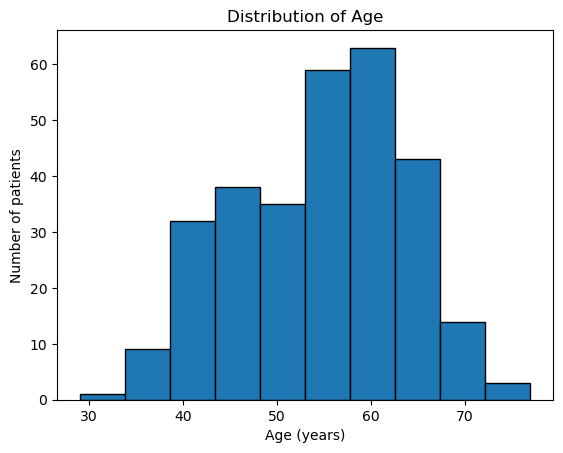

In [19]:
import matplotlib.pyplot as plt

# Histogram of age
plt.figure()
plt.hist(df_clean["age"], bins=10, edgecolor="black")
plt.xlabel("Age (years)")
plt.ylabel("Number of patients")
plt.title("Distribution of Age")
plt.show()

### 6.4 Comparing a Clinical Variable by Outcome

Comparing distributions by outcome group can highlight important
clinical differences.

<Figure size 640x480 with 0 Axes>

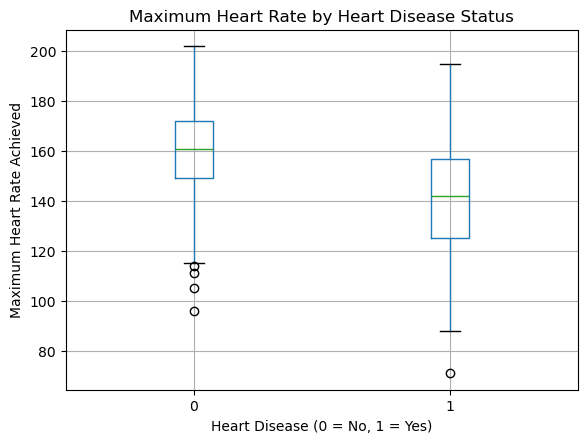

In [18]:
# Boxplot of maximum heart rate by heart disease outcome
plt.figure()
df_clean.boxplot(column="thalach", by="heart_disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Maximum Heart Rate Achieved")
plt.title("Maximum Heart Rate by Heart Disease Status")
plt.suptitle("")
plt.show()

### 6.5 Summary of Exploratory Findings

- Several variables are binary or categorical and consequently show a high
  proportion of zero values, which reflects valid encoding rather than missing data.
- The age distribution is centred on middle-aged and older adults, consistent
  with population-level cardiovascular risk.
- Visual inspection of key variables (e.g. maximum heart rate) suggests
  meaningful differences between outcome groups.

These findings indicate that the dataset is suitable for downstream
analysis and predictive modelling.